In [1]:
# GOOGLE COLAB + DRIVE SETUP
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running on Google Colab')
    from google.colab import drive
    drive.mount('/content/drive')

    # CONFIGURE YOUR DRIVE PATHS HERE
    WORK_DIR    = '/content/drive/MyDrive/MAJOR'
    DATA_DIR    = '/content/drive/MyDrive/MAJOR/data'
    FIGURES_DIR = '/content/drive/MyDrive/MAJOR/figures'
    TABLES_DIR  = '/content/drive/MyDrive/MAJOR/tables'
    MODELS_DIR  = '/content/drive/MyDrive/MAJOR/models'


    for d in [WORK_DIR, DATA_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
        os.makedirs(d, exist_ok=True)
    os.chdir(WORK_DIR)

    import subprocess
    subprocess.run([
        'pip', 'install', '-q',
        'scikit-survival', 'scikit-learn', 'imbalanced-learn',
        'pandas', 'numpy', 'matplotlib', 'seaborn', 'tqdm', 'shap','lifelines'
    ], check=True)

else:
    print('Not on Colab — using local paths')
    WORK_DIR    = os.getcwd()
    DATA_DIR    = WORK_DIR
    FIGURES_DIR = os.path.join(WORK_DIR, 'figures')
    TABLES_DIR  = os.path.join(WORK_DIR, 'tables')
    MODELS_DIR  = os.path.join(WORK_DIR, 'models')
    for d in [FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
        os.makedirs(d, exist_ok=True)

print(f'Data    : {DATA_DIR}')
print(f'Figures : {FIGURES_DIR}')
print(f'Tables  : {TABLES_DIR}')
print(f'Models  : {MODELS_DIR}')
print('Setup complete!')

Running on Google Colab
Mounted at /content/drive
Data    : /content/drive/MyDrive/MAJOR/data
Figures : /content/drive/MyDrive/MAJOR/figures
Tables  : /content/drive/MyDrive/MAJOR/tables
Models  : /content/drive/MyDrive/MAJOR/models
Setup complete!


In [2]:
# IMPORTS & GLOBAL SEEDS
import warnings
warnings.filterwarnings('ignore')
import os, random, time, pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from scipy.cluster.hierarchy import linkage, leaves_list

# scikit-survival — True Random Survival Forest
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score,
    brier_score
)
from sksurv.util import Surv
# imbalanced-learn — SMOTE

from imblearn.over_sampling import SMOTE

# sklearn
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

import shap
import joblib

# Global seeds for full reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Plot styling
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})
C = {'hr': '#C0392B', 'lr': '#2980B9', 'neu': '#7F8C8D',
     'gold': '#F39C12', 'green': '#27AE60', 'purple': '#8E44AD'}

print(f'All libraries loaded   |  SEED = {SEED}')
print(f'NumPy {np.__version__} | Pandas {pd.__version__} | Matplotlib {matplotlib.__version__}')

All libraries loaded   |  SEED = 42
NumPy 2.0.2 | Pandas 2.2.2 | Matplotlib 3.10.0


LOADING THE MODEL AND DATA

In [14]:
# LOAD ALL ASSETS FROM TEMPORAL PROGNOSIS NOTEBOOK

import joblib, json as _json

print('LOADING SAVED ASSETS FROM TEMPORAL PROGNOSIS NOTEBOOK')

# 1. Load trained models
rsf_bb = joblib.load(os.path.join(MODELS_DIR, 'rsf_bb.pkl'))
rsf_sm = joblib.load(os.path.join(MODELS_DIR, 'rsf_sm.pkl'))
cox    = joblib.load(os.path.join(MODELS_DIR, 'cox.pkl'))
scaler = joblib.load(os.path.join(MODELS_DIR, 'scaler.pkl'))

# 2. Load metadata (features, indices, seed, horizon)
with open(os.path.join(MODELS_DIR, 'model_meta.json')) as _f:
    _meta = _json.load(_f)

FEATURES_18         = _meta['features_18']
FEATURE_LABELS      = _meta['feature_labels']
CONTINUOUS_FEATURES = _meta['continuous_features']
CONT_IDX            = _meta['cont_idx']
SEED                = _meta['seed']
HORIZON             = _meta['horizon']
ROC_THRESHOLD       = _meta['km_threshold']
print(f'Metadata loaded — {len(FEATURES_18)} features | SEED={SEED} | HORIZON={HORIZON}')

# 3. Load preprocessed data splits
PROCESSED_DIR = '/content/drive/MyDrive/MAJOR/processed'

df_train = pd.read_csv(os.path.join(PROCESSED_DIR, 'train_processed.csv'))
df_val   = pd.read_csv(os.path.join(PROCESSED_DIR, 'validation_processed.csv'))
df_test  = pd.read_csv(os.path.join(PROCESSED_DIR, 'test_processed.csv'))

X_train = df_train[FEATURES_18].values.astype(float)
X_val   = df_val[FEATURES_18].values.astype(float)
X_test  = df_test[FEATURES_18].values.astype(float)

T_train = df_train['Time'].values.astype(float)
T_val   = df_val['Time'].values.astype(float)
T_test  = df_test['Time'].values.astype(float)

E_train = df_train['Event'].values.astype(bool)
E_val   = df_val['Event'].values.astype(bool)
E_test  = df_test['Event'].values.astype(bool)

print(f'     Train : {X_train.shape}  events={E_train.sum()} ({E_train.mean()*100:.1f}%)')
print(f'     Val   : {X_val.shape}  events={E_val.sum()} ({E_val.mean()*100:.1f}%)')
print(f'     Test  : {X_test.shape}  events={E_test.sum()} ({E_test.mean()*100:.1f}%)')

# 4. Rebuild sksurv structured survival arrays
from sksurv.util import Surv
y_train = Surv.from_arrays(event=E_train, time=T_train)
y_val   = Surv.from_arrays(event=E_val,   time=T_val)
y_test  = Surv.from_arrays(event=E_test,  time=T_test)

# 5. Verify rsf_bb works on loaded data
_sample_risk = rsf_bb.predict(X_test[:3])
print(f'rsf_bb sanity check — sample risks: {_sample_risk.round(4)}')


LOADING SAVED ASSETS FROM TEMPORAL PROGNOSIS NOTEBOOK
[OK] Models loaded: rsf_bb, rsf_sm, cox, scaler
[OK] Metadata loaded — 18 features | SEED=42 | HORIZON=7.0
[OK] Data splits loaded:
     Train : (2391, 18)  events=454 (19.0%)
     Val   : (798, 18)  events=151 (18.9%)
     Test  : (798, 18)  events=152 (19.0%)
[OK] Survival arrays rebuilt: y_train, y_val, y_test
[OK] rsf_bb sanity check — sample risks: [89.5241 15.0732 30.2173]

[ALL ASSETS READY] Proceed to Explainable AI cells.


In [15]:

# EXPLAINER SETUP + SHAP COMPUTATION


print('='*65)
print('PHASE 4: Novelty 2 — Explainable AI (Permutation SHAP)')
print('  Explainer : shap.Explainer (algorithm=permutation)')
print('  Target    : RSF cumulative hazard score (risk proxy)')
print('  Reason    : TreeExplainer gives InvalidModel on sksurv')
print('='*65)

# Prediction wrapper
def rsf_predict(X_array):
    """Returns cumulative hazard (risk score) for SHAP."""
    return rsf_bb.predict(X_array)

# Background: 100 random train samples
rng_shap = np.random.RandomState(SEED)
bg_idx   = rng_shap.choice(len(X_train), size=100, replace=False)
X_bg     = X_train[bg_idx]

# Independent masker instead of shap.kmeans
masker = shap.maskers.Independent(X_bg, max_samples=100)

# Build explainer
explainer = shap.Explainer(
    rsf_predict,
    masker,
    algorithm='permutation',
    seed=SEED
)

# Compute SHAP values on test subset (100 patients)
N_SHAP   = min(100, len(X_test))
rng_sub  = np.random.RandomState(SEED + 1)
shap_idx = rng_sub.choice(len(X_test), size=N_SHAP, replace=False)
X_shap   = X_test[shap_idx]

print(f'[SHAP] Computing Permutation SHAP on {N_SHAP} test patients...')
print(f'       max_evals = 5 × 18 + 1 = {5 * len(FEATURES_18) + 1} per sample')

# Increase max_evals for stable SHAP values
shap_explanation = explainer(X_shap, max_evals=5 * len(FEATURES_18) + 1)
shap_values      = shap_explanation.values

# base_values is per-patient array, take mean
base_val = float(np.mean(shap_explanation.base_values))

# Global importance table
mean_abs_shap = np.abs(shap_values).mean(axis=0)

ABLATION_PAPER = [
    1.016, 1.001, 0.995, 1.041, 1.013,
    1.052, 1.005, 1.106, 1.016, 1.011,
    1.022, 1.056, 1.011, 1.141,
    1.044, 1.018, 1.013, 1.021
]
shap_df = pd.DataFrame({
    'Feature'        : FEATURE_LABELS,
    'SHAP_Importance': mean_abs_shap,
    'Ablation_Paper' : ABLATION_PAPER
}).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)

print(f'\n{"Rank":<5}{"Feature":<22}{"SHAP (Perm)":>13}{"Ablation(Paper)":>16}')
print('-'*58)
for i, row in shap_df.iterrows():
    mark = ' ★' if i < 7 else ''
    print(f'{i+1:<5}{row["Feature"]:<22}'
          f'{row["SHAP_Importance"]:>13.4f}'
          f'{row["Ablation_Paper"]:>16.3f}{mark}')
print(f'\n[SHAP] Base value (expected hazard) : {base_val:.4f}')
print(f'[SHAP] Top feature                  : {shap_df["Feature"].iloc[0]}')
print('★ = Top 7 most influential features')

PHASE 4: Novelty 2 — Explainable AI (Permutation SHAP)
  Explainer : shap.Explainer (algorithm=permutation)
  Target    : RSF cumulative hazard score (risk proxy)
  Reason    : TreeExplainer gives InvalidModel on sksurv
[SHAP] Computing Permutation SHAP on 100 test patients...
       max_evals = 5 × 18 + 1 = 91 per sample


PermutationExplainer explainer: 101it [26:11, 15.72s/it]


Rank Feature                 SHAP (Perm) Ablation(Paper)
----------------------------------------------------------
1    LVEF                        27.7648           1.106 ★
2    Age                         19.9682           1.001 ★
3    Creatinine                  11.1267           1.018 ★
4    Dyslipidemia                 6.4472           1.141 ★
5    Vessels                      6.0991           1.021 ★
6    Diabetes                     5.0129           1.056 ★
7    Atrial Fib.                  3.7933           1.044 ★
8    Acute MI                     3.6105           1.005
9    Angiography                  3.4787           1.013
10   Post IDC                     3.3667           1.011
11   Prev. CABG                   2.6011           1.041
12   Gender                       1.8286           1.016
13   Prev. MI                     1.6533           1.052
14   Ischemia                     1.5893           1.016
15   Smoke                        1.1832           1.022
16   Angina   

SHAP Global Summary — Beeswarm Plot


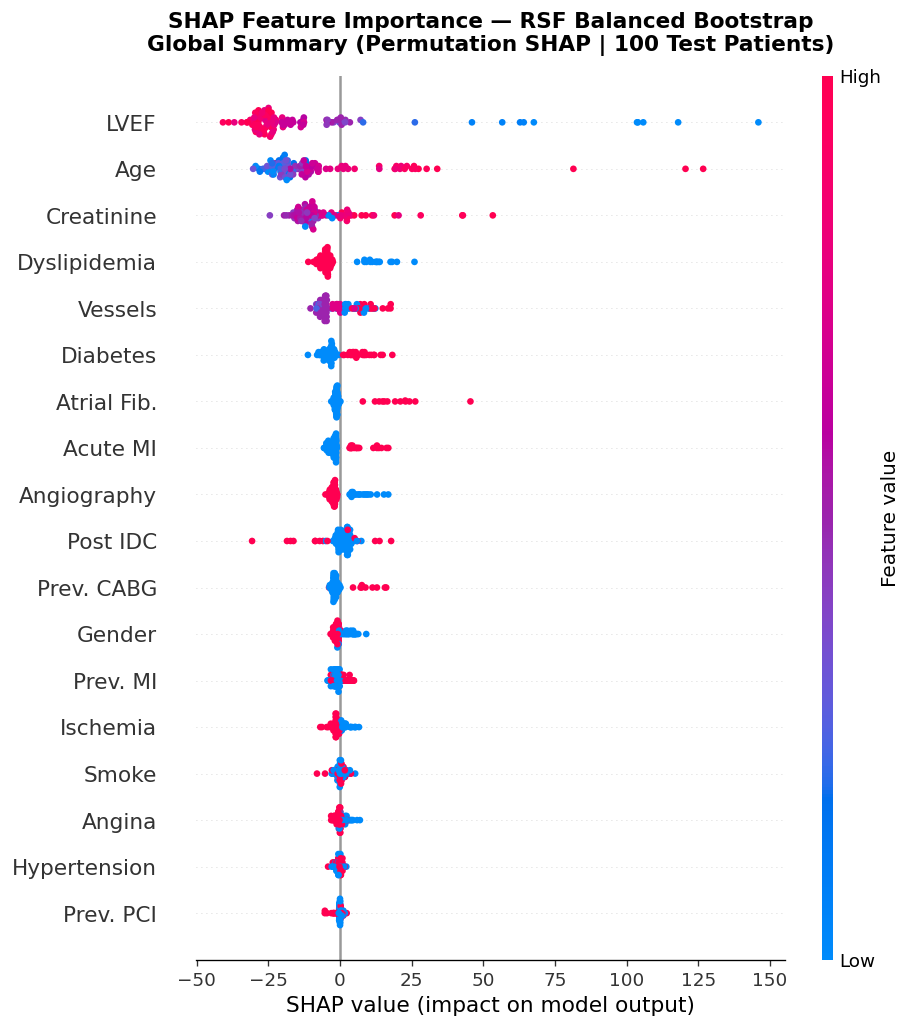

[PLOT] SHAP Beeswarm ✓


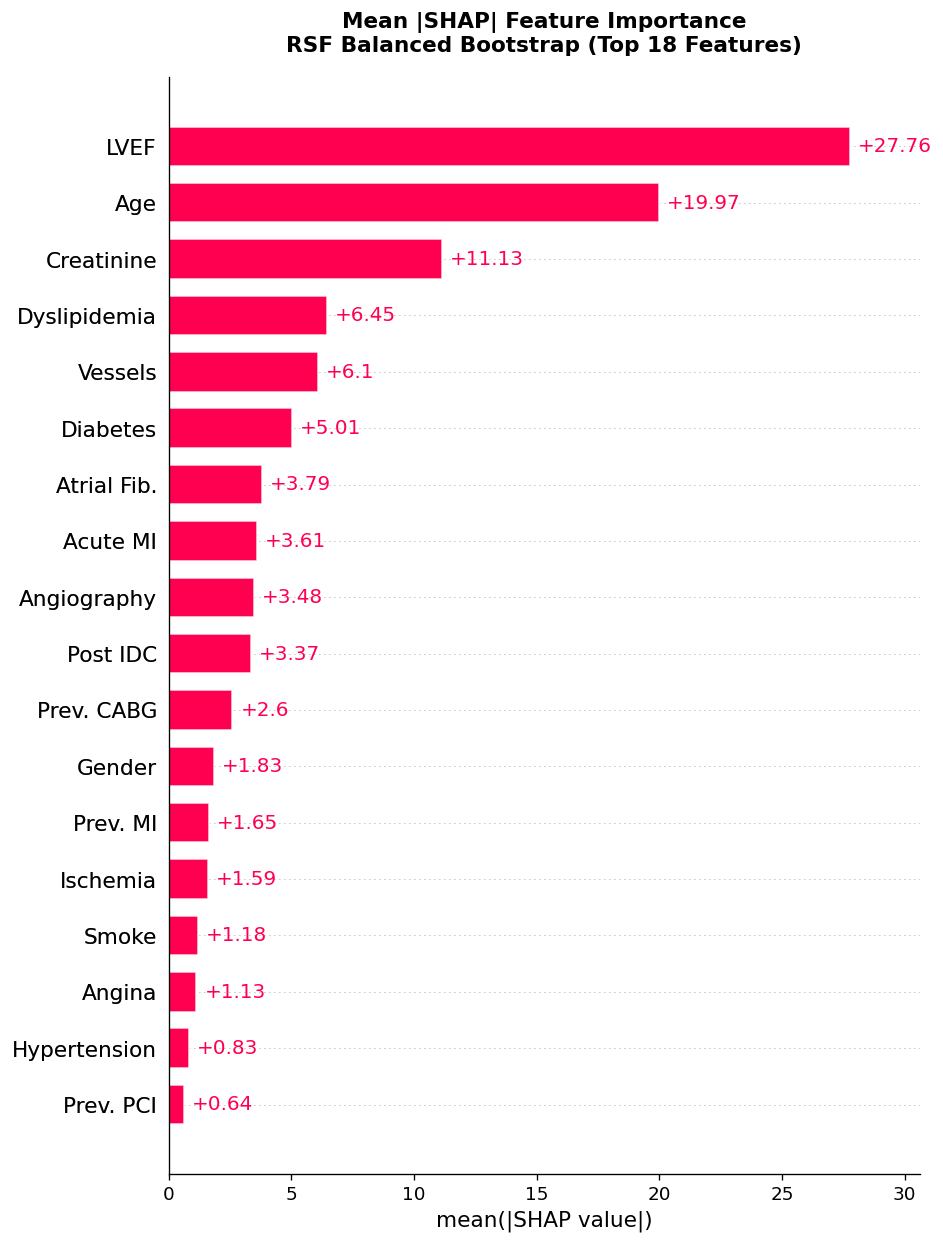

In [16]:
#SHAP GLOBAL SUMMARY (BEESWARM)

print('SHAP Global Summary — Beeswarm Plot')

# Build proper Explanation object with feature names
explanation_named = shap.Explanation(
    values          = shap_values,
    base_values     = shap_explanation.base_values,
    data            = X_shap,
    feature_names   = FEATURE_LABELS
)

# Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(
    explanation_named,
    max_display=18,
    show=False
)
plt.title(
    'SHAP Feature Importance — RSF Balanced Bootstrap\n'
    'Global Summary (Permutation SHAP | 100 Test Patients)',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_shap_beeswarm.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print('[PLOT] SHAP Beeswarm ✓')

# Bar Plot (mean absolute SHAP)
plt.figure(figsize=(9, 7))
shap.plots.bar(
    explanation_named,
    max_display=18,
    show=False
)
plt.title(
    'Mean |SHAP| Feature Importance\n'
    'RSF Balanced Bootstrap (Top 18 Features)',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_shap_bar.png'),
            bbox_inches='tight', dpi=150)
plt.show()

SHAP Dependence Plots — Top 3 Features


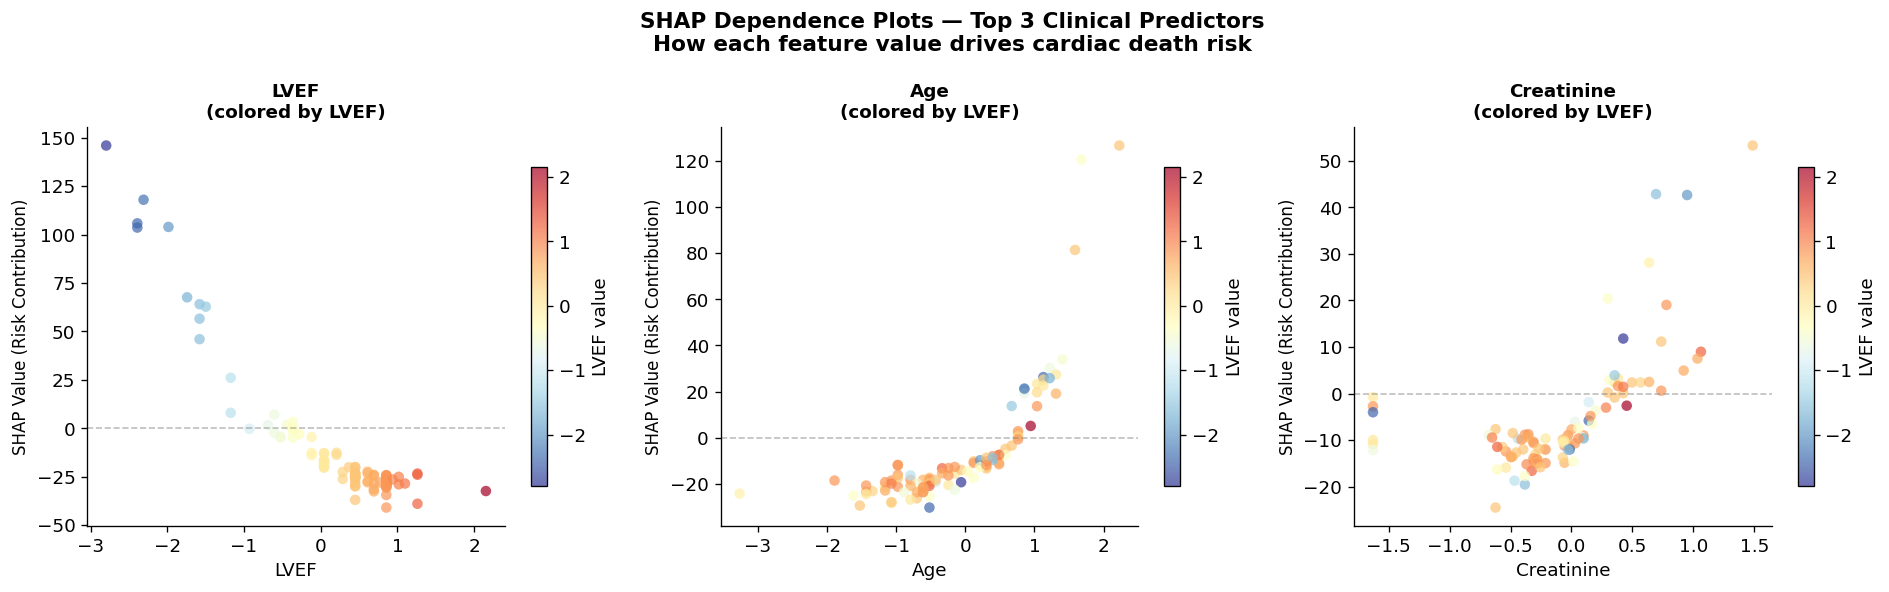

In [17]:
# SHAP DEPENDENCE PLOTS
# Top 3 features: LVEF, Age, Creatinine

print('SHAP Dependence Plots — Top 3 Features')


TOP_FEATURES = ['LVEF', 'Age', 'Creatinine']
TOP_LABELS   = ['LVEF', 'Age', 'Creatinine']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'SHAP Dependence Plots — Top 3 Clinical Predictors\n'
    'How each feature value drives cardiac death risk',
    fontsize=13, fontweight='bold'
)

for ax, feat, label in zip(axes, TOP_FEATURES, TOP_LABELS):
    feat_idx  = FEATURE_LABELS.index(label)
    feat_vals = X_shap[:, feat_idx]
    shap_vals = shap_values[:, feat_idx]

    # Color by LVEF for all plots (most dominant feature)
    lvef_idx  = FEATURE_LABELS.index('LVEF')
    color_vals = X_shap[:, lvef_idx]

    sc = ax.scatter(
        feat_vals, shap_vals,
        c=color_vals, cmap='RdYlBu_r',
        alpha=0.7, s=40, edgecolors='none'
    )
    ax.axhline(0, color='gray', lw=1, ls='--', alpha=0.5)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('SHAP Value (Risk Contribution)', fontsize=10)
    ax.set_title(f'{label}\n(colored by LVEF)', fontweight='bold', fontsize=11)
    plt.colorbar(sc, ax=ax, label='LVEF value', shrink=0.8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_shap_dependence.png'),
            bbox_inches='tight', dpi=150)
plt.show()

Local Waterfall — Individual Patient Explanation
Selected patients:
  High Risk  → index 89 | risk=279.27
  Borderline → index 93    | risk=29.80
  Low Risk   → index 46  | risk=4.07


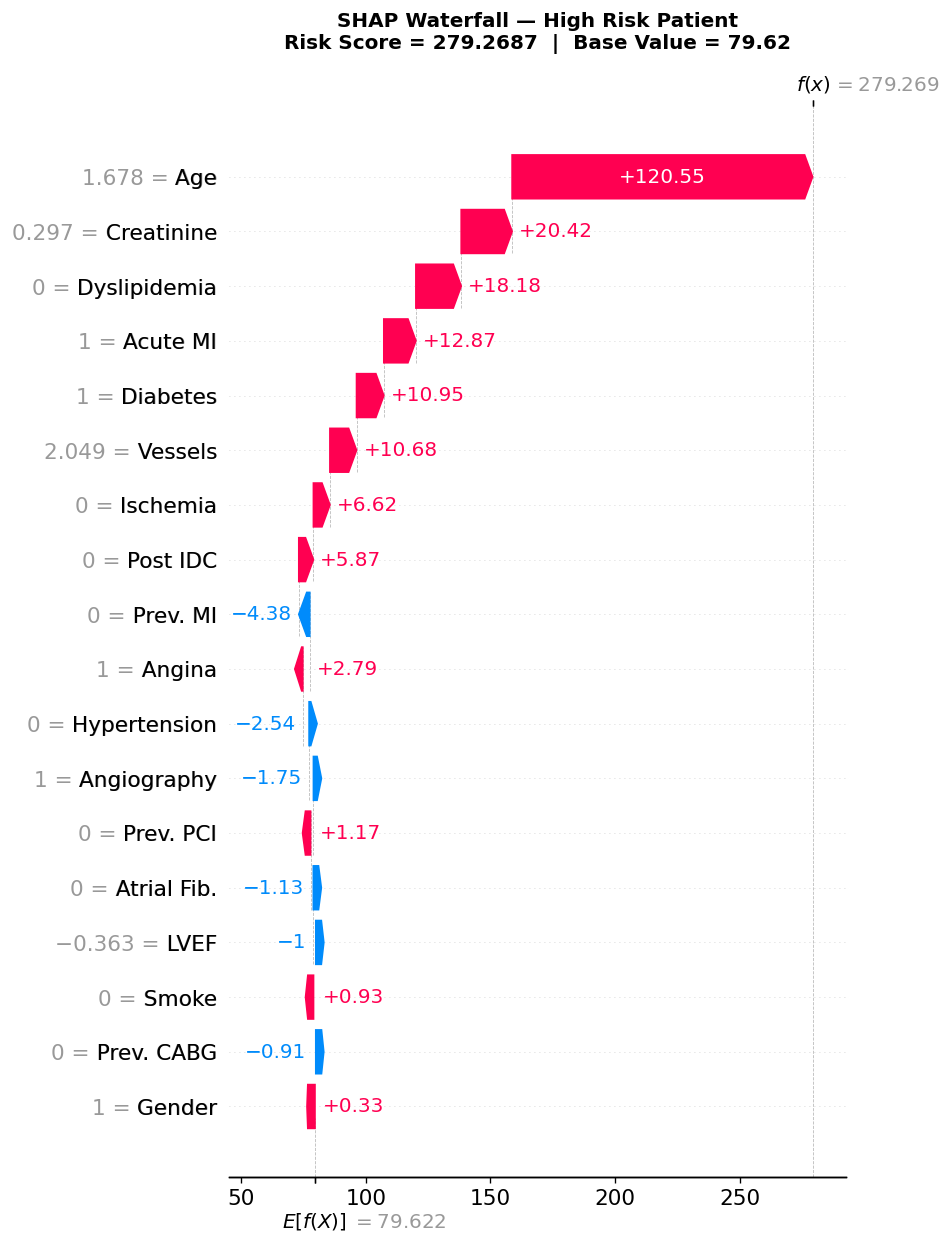

[PLOT] Waterfall — High Risk Patient ✓


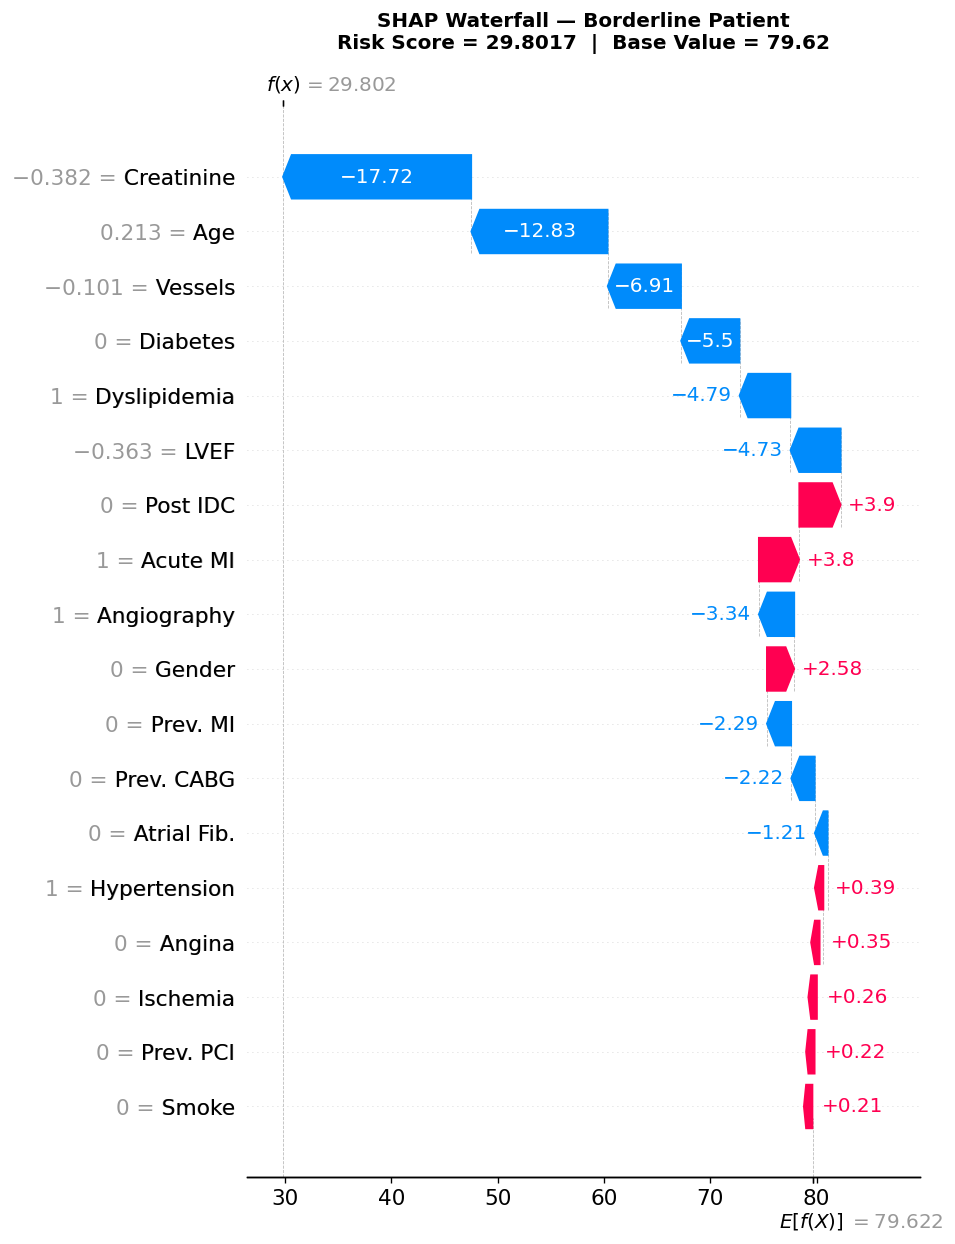

[PLOT] Waterfall — Borderline Patient ✓


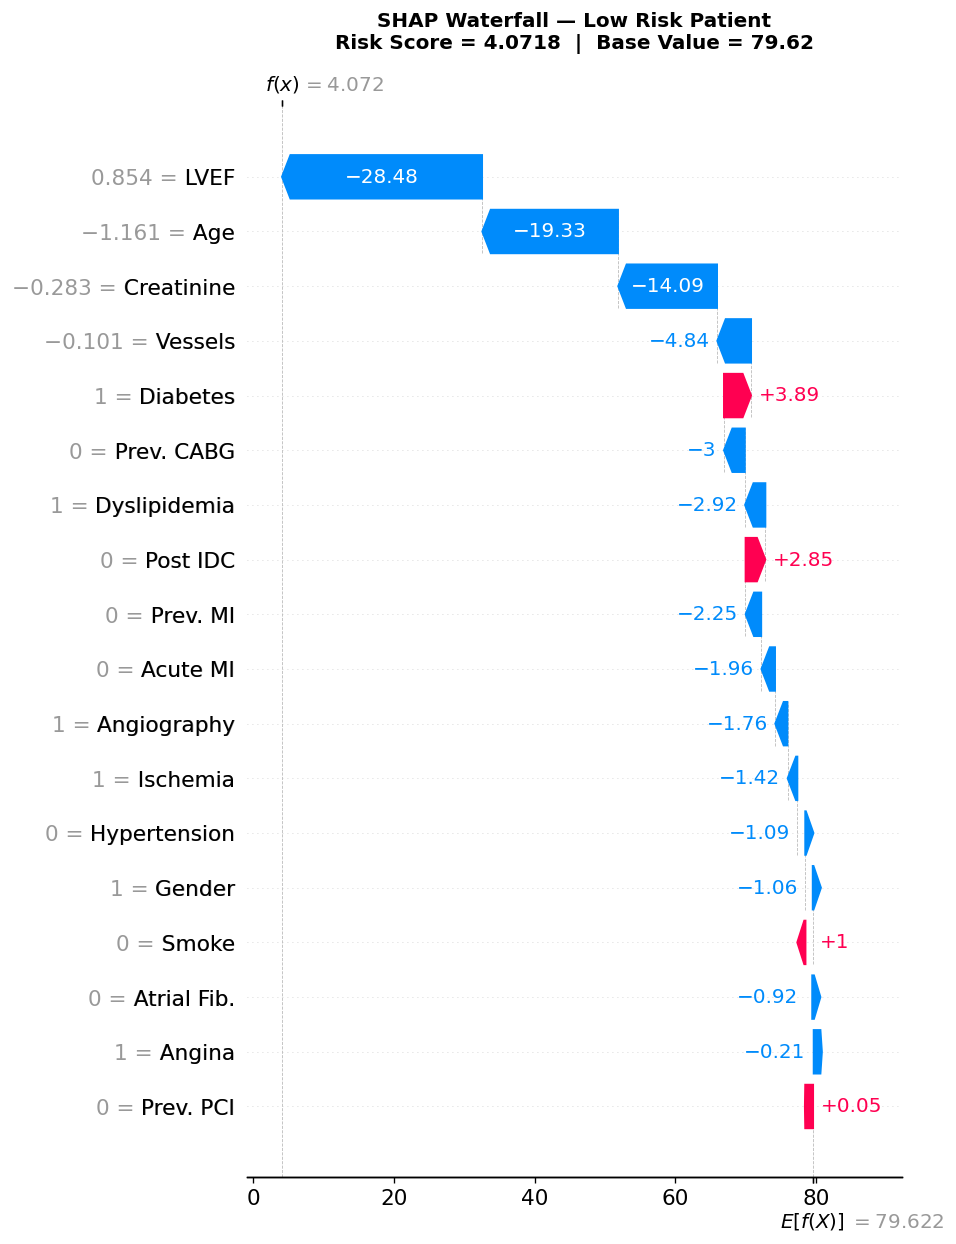

[PLOT] Waterfall — Low Risk Patient ✓


In [18]:
# LOCAL WATERFALL EXPLANATION
# Explain 3 patients: High Risk, Low Risk, Borderline

print('Local Waterfall — Individual Patient Explanation')


# representative patients
risk_scores   = rsf_bb.predict(X_shap)
high_risk_idx = int(np.argmax(risk_scores))          # most at risk
low_risk_idx  = int(np.argmin(risk_scores))          # least at risk
mid_score     = np.median(risk_scores)
border_idx    = int(np.argmin(np.abs(risk_scores - mid_score)))  # borderline

patients = [
    (high_risk_idx, 'High Risk Patient',    C['hr']),
    (border_idx,    'Borderline Patient',   C['gold']),
    (low_risk_idx,  'Low Risk Patient',     C['lr']),
]

print(f'Selected patients:')
print(f'  High Risk  → index {high_risk_idx} | risk={risk_scores[high_risk_idx]:.2f}')
print(f'  Borderline → index {border_idx}    | risk={risk_scores[border_idx]:.2f}')
print(f'  Low Risk   → index {low_risk_idx}  | risk={risk_scores[low_risk_idx]:.2f}')

# Plot waterfall for each patient
for pat_idx, pat_name, pat_color in patients:
    single_exp = shap.Explanation(
        values        = shap_values[pat_idx],
        base_values   = float(shap_explanation.base_values[pat_idx]),
        data          = X_shap[pat_idx],
        feature_names = FEATURE_LABELS
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(single_exp, max_display=18, show=False)
    plt.title(
        f'SHAP Waterfall — {pat_name}\n'
        f'Risk Score = {risk_scores[pat_idx]:.4f}  |  '
        f'Base Value = {float(shap_explanation.base_values[pat_idx]):.2f}',
        fontsize=12, fontweight='bold', pad=15
    )
    plt.tight_layout()
    fname = pat_name.lower().replace(' ', '_')
    plt.savefig(os.path.join(FIGURES_DIR, f'fig_shap_waterfall_{fname}.png'),
                bbox_inches='tight', dpi=150)
    plt.show()
    print(f'[PLOT] Waterfall — {pat_name} ✓')
